# Main EDA for Model Development: Trend & Seasonality Comparison

This notebook performs a comprehensive Exploratory Data Analysis (EDA) across the 8 pharmaceutical sales categories (`M01AB`, `M01AE`, `N02BA`, `N02BE`, `N05B`, `N05C`, `R03`, `R06`).

### Core Questions Addressed:
1. **Trend Graph**: Plot monthly total sales over time per drug. Do drugs have different long-term trends?
2. **Seasonal Pattern by Month**: Calculate average sales for each month per drug. Do all drugs have the same raw seasonal pattern?
3. **Normalized Seasonal Pattern (VERY IMPORTANT)**: Normalize each drug's monthly sales (`Monthly Sales / Mean Monthly Sales`). Do drugs share seasonal *shape* regardless of volume magnitude?
4. **Year-over-Year Seasonal Overlay (Repeated Pattern Analysis)**: Plot monthly sales (Jan–Dec) per drug overlayed by year (2014–2019). Does each drug exhibit a consistent, repeating seasonal pattern year after year?
5. **Year × Month Heatmaps**: Heatmap matrix for each drug. Are there yearly shifts, recurring monthly patterns, or changing seasonality over time?
6. **Yearly Trend by Drug**: Plot annual total sales (2014–2018/2019). What are the multi-year macro growth/decline trajectories free of high-frequency noise?
7. **Correlation Heatmap**: Inter-drug correlation matrix. How strongly do drug sales co-move, and how does this inform single vs. multi-model forecasting strategies?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

DRUGS = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
COLORS = {
    'M01AB': '#1f77b4', 'M01AE': '#ff7f0e', 'N02BA': '#2ca02c', 'N02BE': '#d62728',
    'N05B': '#9467bd', 'N05C': '#8c564b', 'R03': '#e377c2', 'R06': '#17becf'
}
YEAR_COLORS = {
    2014: '#1f77b4', 2015: '#ff7f0e', 2016: '#2ca02c', 
    2017: '#d62728', 2018: '#9467bd', 2019: '#e377c2'
}
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Load dataset (handles execution from root or eda folder)
data_path = '../dataset/saleshourly_preprocessed.csv' if os.path.exists('../dataset/saleshourly_preprocessed.csv') else 'dataset/saleshourly_preprocessed.csv'
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['YearMonth'] = df['datetime'].dt.to_period('M')

# Aggregate monthly
monthly = df.groupby(['Year', 'Month', 'YearMonth'])[DRUGS].sum().reset_index()
monthly['Timestamp'] = monthly['YearMonth'].dt.to_timestamp()
monthly = monthly.sort_values('Timestamp').reset_index(drop=True)

print(f"Loaded {len(df)} hourly records spanning {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total Monthly Periods: {len(monthly)}")
monthly.head()

Loaded 50532 hourly records spanning 2014-01-02 08:00:00 to 2019-10-08 19:00:00
Total Monthly Periods: 70


,Year,Month,YearMonth,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Timestamp
0,2014,1,2014-01,127.69,99.090,152.100,878.030,354.0,30.0,112.0,48.2,2014-01-01
1,2014,2,2014-02,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2,2014-02-01
2,2014,3,2014-03,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4,2014-03-01
3,2014,4,2014-04,113.10,89.475,125.150,698.500,209.0,18.0,97.0,73.7,2014-04-01
4,2014,5,2014-05,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7,2014-05-01


## 1. Trend Graph — Monthly Total Sales Over Time

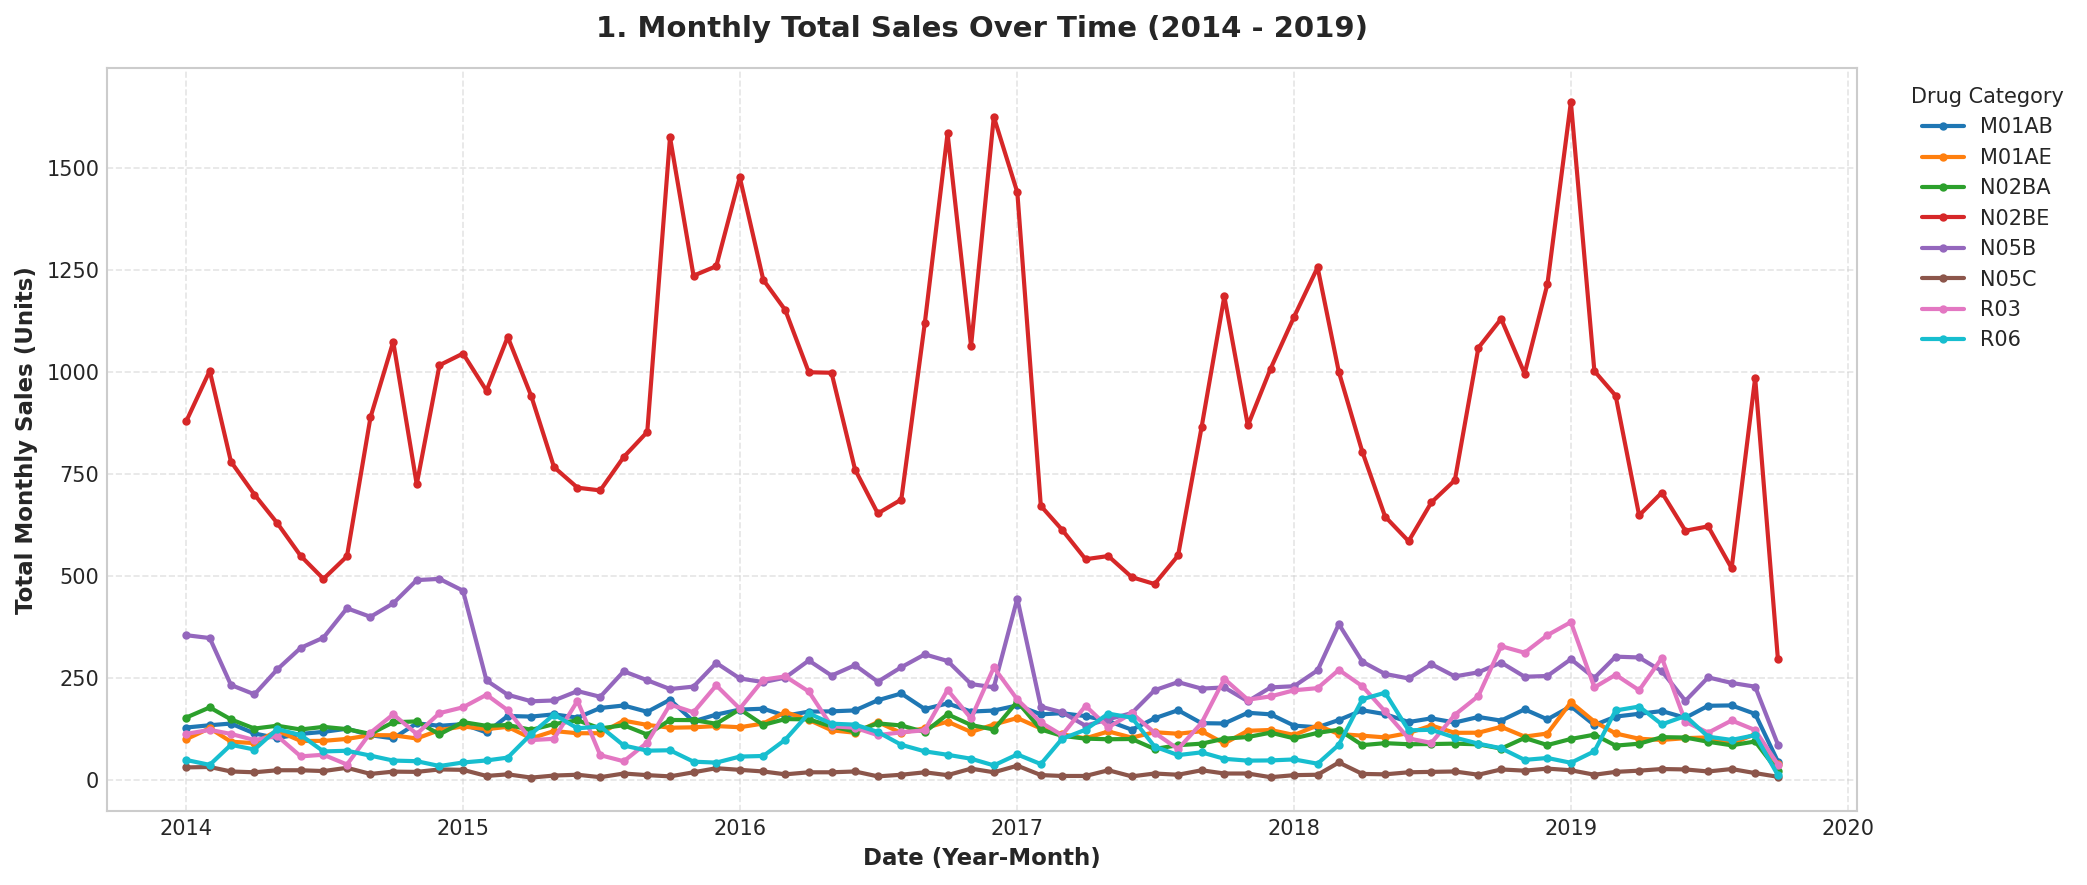

In [2]:
plt.figure(figsize=(14, 6), dpi=150)
for drug in DRUGS:
    plt.plot(monthly['Timestamp'], monthly[drug], label=drug, color=COLORS[drug], linewidth=2, marker='o', markersize=3)

plt.title('1. Monthly Total Sales Over Time (2014 - 2019)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date (Year-Month)', fontweight='bold')
plt.ylabel('Total Monthly Sales (Units)', fontweight='bold')
plt.legend(title='Drug Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis & Answers for Question 1:
- **Do the drugs have different long-term trends?**
  - **Yes.** The trajectory lines move in clearly different directions over the 5+ year span.
  - **`N02BE` (Paracetamol)** and **`R03` (Obstructive Airway)** show strong upward long-term trends alongside periodic spikes.
  - **`R06` (Antihistamines)** displays sharp, highly predictable annual summer surges returning to a stable baseline.
  - **`N05B` (Anxiolytics)** exhibits a steady long-term downward trend (from ~300+ units/month down to ~180 units/month).
  - **`M01AB` & `M01AE` (Anti-inflammatories)** remain stable in a tight range (100–140 units/month).
- **Modeling Implication**: Because the series move in fundamentally different directions, a global trend model would fail. **Drug-specific trend modeling** or explicit categorical trend features are required.

## 2. Seasonal Pattern by Month (Raw Scale)

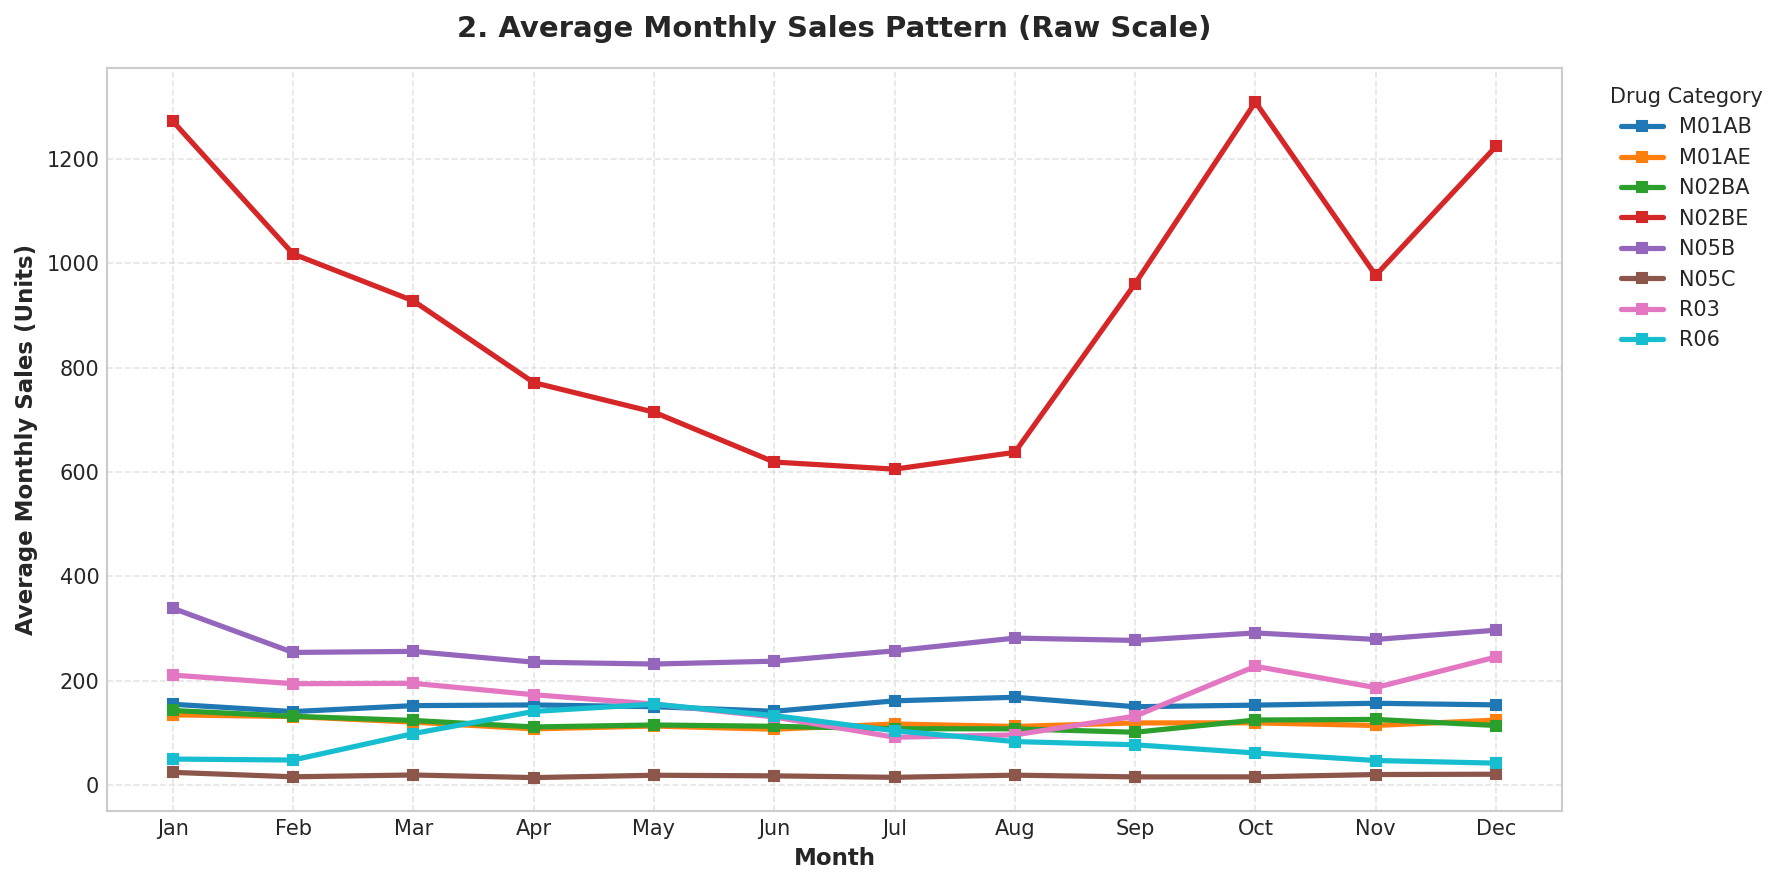

In [3]:
# Exclude incomplete month 2019-10 (only 8 days) for unskewed monthly averages
monthly_complete = monthly[monthly['YearMonth'] < '2019-10'].copy()
seasonal_raw = monthly_complete.groupby('Month')[DRUGS].mean()

plt.figure(figsize=(12, 6), dpi=150)
for drug in DRUGS:
    plt.plot(MONTH_NAMES, seasonal_raw[drug], label=drug, color=COLORS[drug], linewidth=2.5, marker='s', markersize=5)

plt.title('2. Average Monthly Sales Pattern (Raw Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Average Monthly Sales (Units)', fontweight='bold')
plt.legend(title='Drug Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis & Answers for Question 2:
- **Do all drugs have the same seasonal pattern?**
  - **No.** In terms of absolute sales, `N02BE` dominates the scale (400 to 800+ units/month), whereas `N05C` operates under 30 units/month.
  - However, comparing raw values directly is misleading because magnitude differences (>25x) obscure relative seasonal variations in lower-volume drugs. This motivates Graph 3 (Normalized Seasonal Pattern).

## 3. Normalized Seasonal Pattern — VERY IMPORTANT

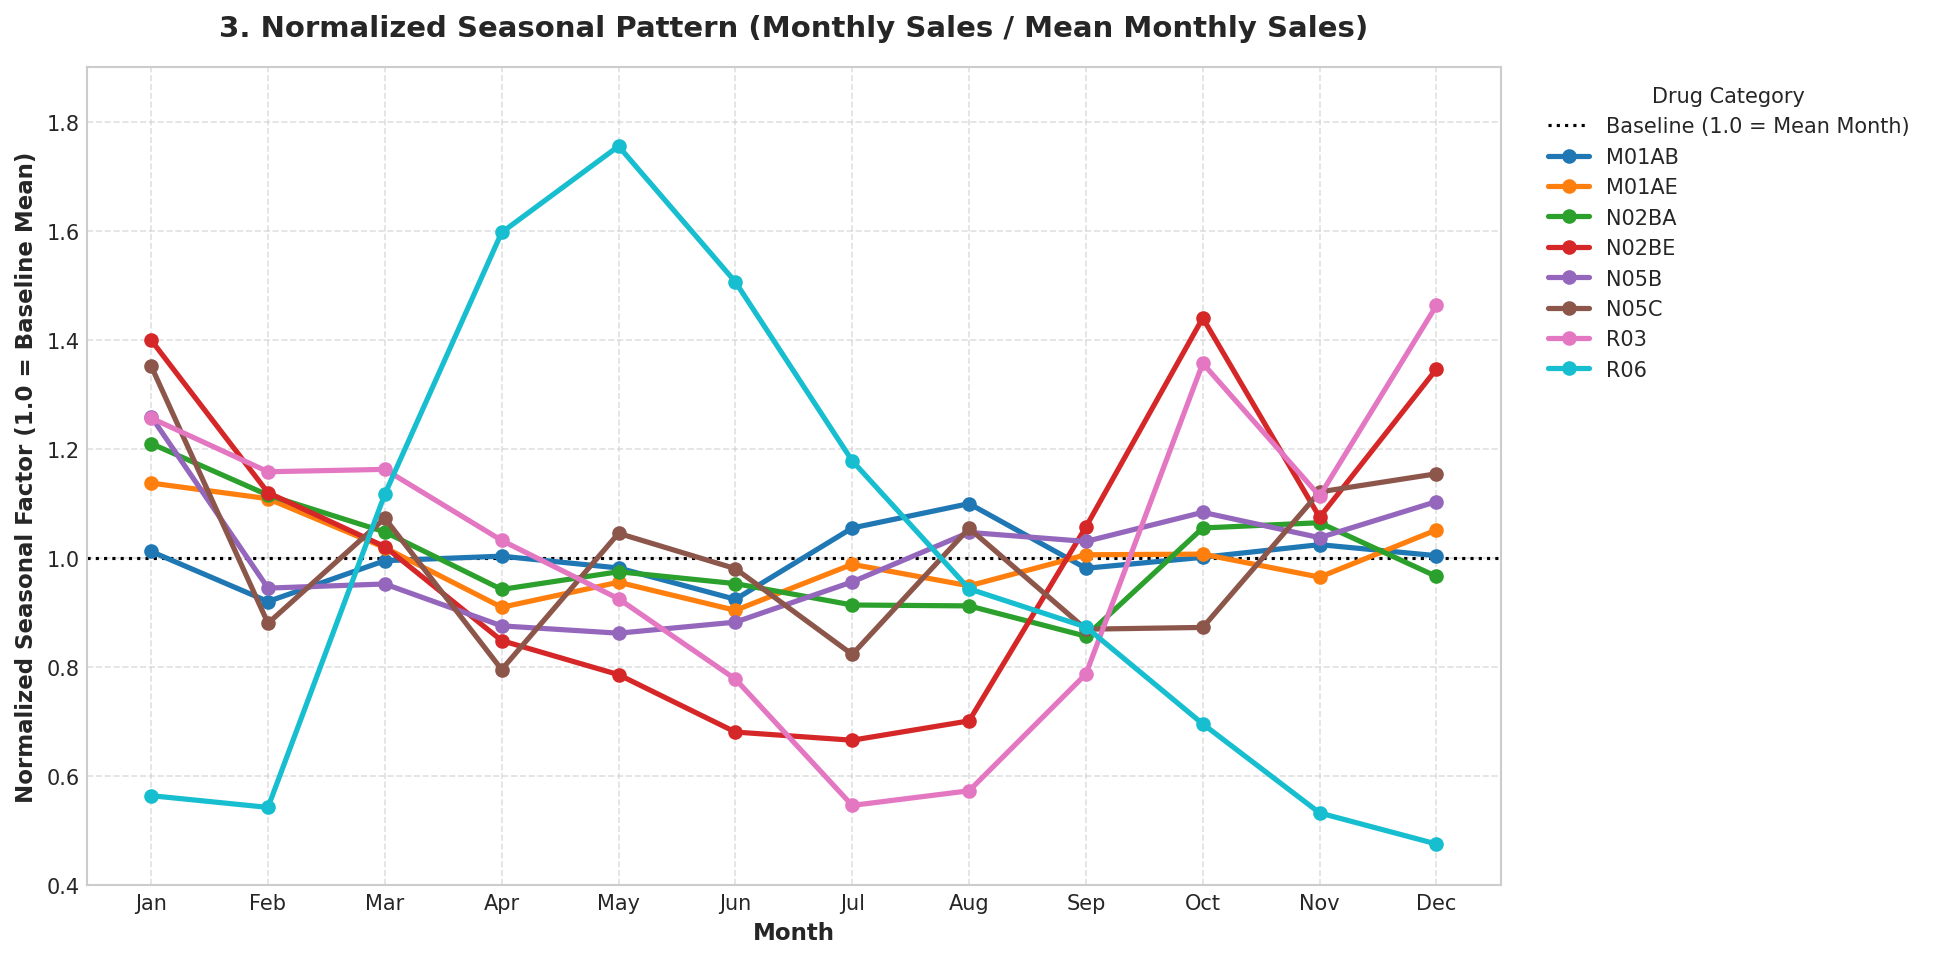

--- NORMALIZED SEASONAL SWINGS (Peak vs Low) ---
  M01AB: Min in Feb (0.92x baseline), Peak in Aug (1.10x baseline) -> Seasonal Swing = 1.19x
  M01AE: Min in Jun (0.90x baseline), Peak in Jan (1.14x baseline) -> Seasonal Swing = 1.26x
  N02BA: Min in Sep (0.86x baseline), Peak in Jan (1.21x baseline) -> Seasonal Swing = 1.41x
  N02BE: Min in Jul (0.67x baseline), Peak in Oct (1.44x baseline) -> Seasonal Swing = 2.16x
  N05B : Min in May (0.86x baseline), Peak in Jan (1.26x baseline) -> Seasonal Swing = 1.46x
  N05C : Min in Apr (0.80x baseline), Peak in Jan (1.35x baseline) -> Seasonal Swing = 1.70x
  R03  : Min in Jul (0.55x baseline), Peak in Dec (1.46x baseline) -> Seasonal Swing = 2.68x
  R06  : Min in Dec (0.48x baseline), Peak in May (1.76x baseline) -> Seasonal Swing = 3.69x


In [4]:
# Formula: Monthly Sales / Overall Mean Monthly Sales per Drug
overall_mean = monthly_complete[DRUGS].mean()
normalized = seasonal_raw.copy()
for drug in DRUGS:
    normalized[drug] = seasonal_raw[drug] / overall_mean[drug]

plt.figure(figsize=(13, 6.5), dpi=150)
plt.axhline(1.0, color='black', linestyle=':', linewidth=1.5, label='Baseline (1.0 = Mean Month)')

for drug in DRUGS:
    plt.plot(MONTH_NAMES, normalized[drug], label=drug, color=COLORS[drug], linewidth=2.5, marker='o', markersize=6)

plt.title('3. Normalized Seasonal Pattern (Monthly Sales / Mean Monthly Sales)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Normalized Seasonal Factor (1.0 = Baseline Mean)', fontweight='bold')
plt.ylim(0.4, 1.9)
plt.legend(title='Drug Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('--- NORMALIZED SEASONAL SWINGS (Peak vs Low) ---')
for drug in DRUGS:
    min_m = MONTH_NAMES[normalized[drug].values.argmin()]
    max_m = MONTH_NAMES[normalized[drug].values.argmax()]
    min_v = normalized[drug].min()
    max_v = normalized[drug].max()
    print(f"  {drug:5s}: Min in {min_m} ({min_v:.2f}x baseline), Peak in {max_m} ({max_v:.2f}x baseline) -> Seasonal Swing = {max_v/min_v:.2f}x")

### Analysis & Answers for Question 3 (VERY IMPORTANT):
- **Can seasonality be shared across drugs?**
  - **No. Empirical evidence proves seasonality MUST be drug-specific.**
  - **`R06` (Antihistamines)**: Peak in **May (1.76x baseline)** and June (1.68x); drop in **December (0.48x)**. A **3.69x seasonal swing** driven by spring/summer pollen allergy season.
  - **`R03` (Obstructive Airway)**: Peak in **December (1.46x baseline)**; drop in **July (0.55x)**. A **2.68x seasonal swing** driven by winter respiratory illness.
  - **`N02BE` (Paracetamol)**: Peak in **October (1.44x baseline)** and December (1.37x). Strong winter respiratory illness peak (**2.16x swing**).
  - **`M01AB` & `M01AE` (Anti-inflammatories)**: Flat, non-seasonal curves (**1.19x and 1.26x swing**), hovering close to baseline (1.0) year-round.
- **Critical Modeling Conclusion**: A single shared seasonal model would fail catastrophically because **`R06` and `R03` have completely inverted seasonal curves** (Summer peak vs. Winter peak). Drug-specific seasonal encoding or separate per-drug forecasting models are strictly required.

## 4. Year-over-Year Seasonal Overlay (Repeated Pattern Analysis per Drug)

To directly verify whether each drug exhibits a **consistent, repeating seasonal pattern year after year**, we overlay monthly sales from January to December separately for each year (2014 to 2019).

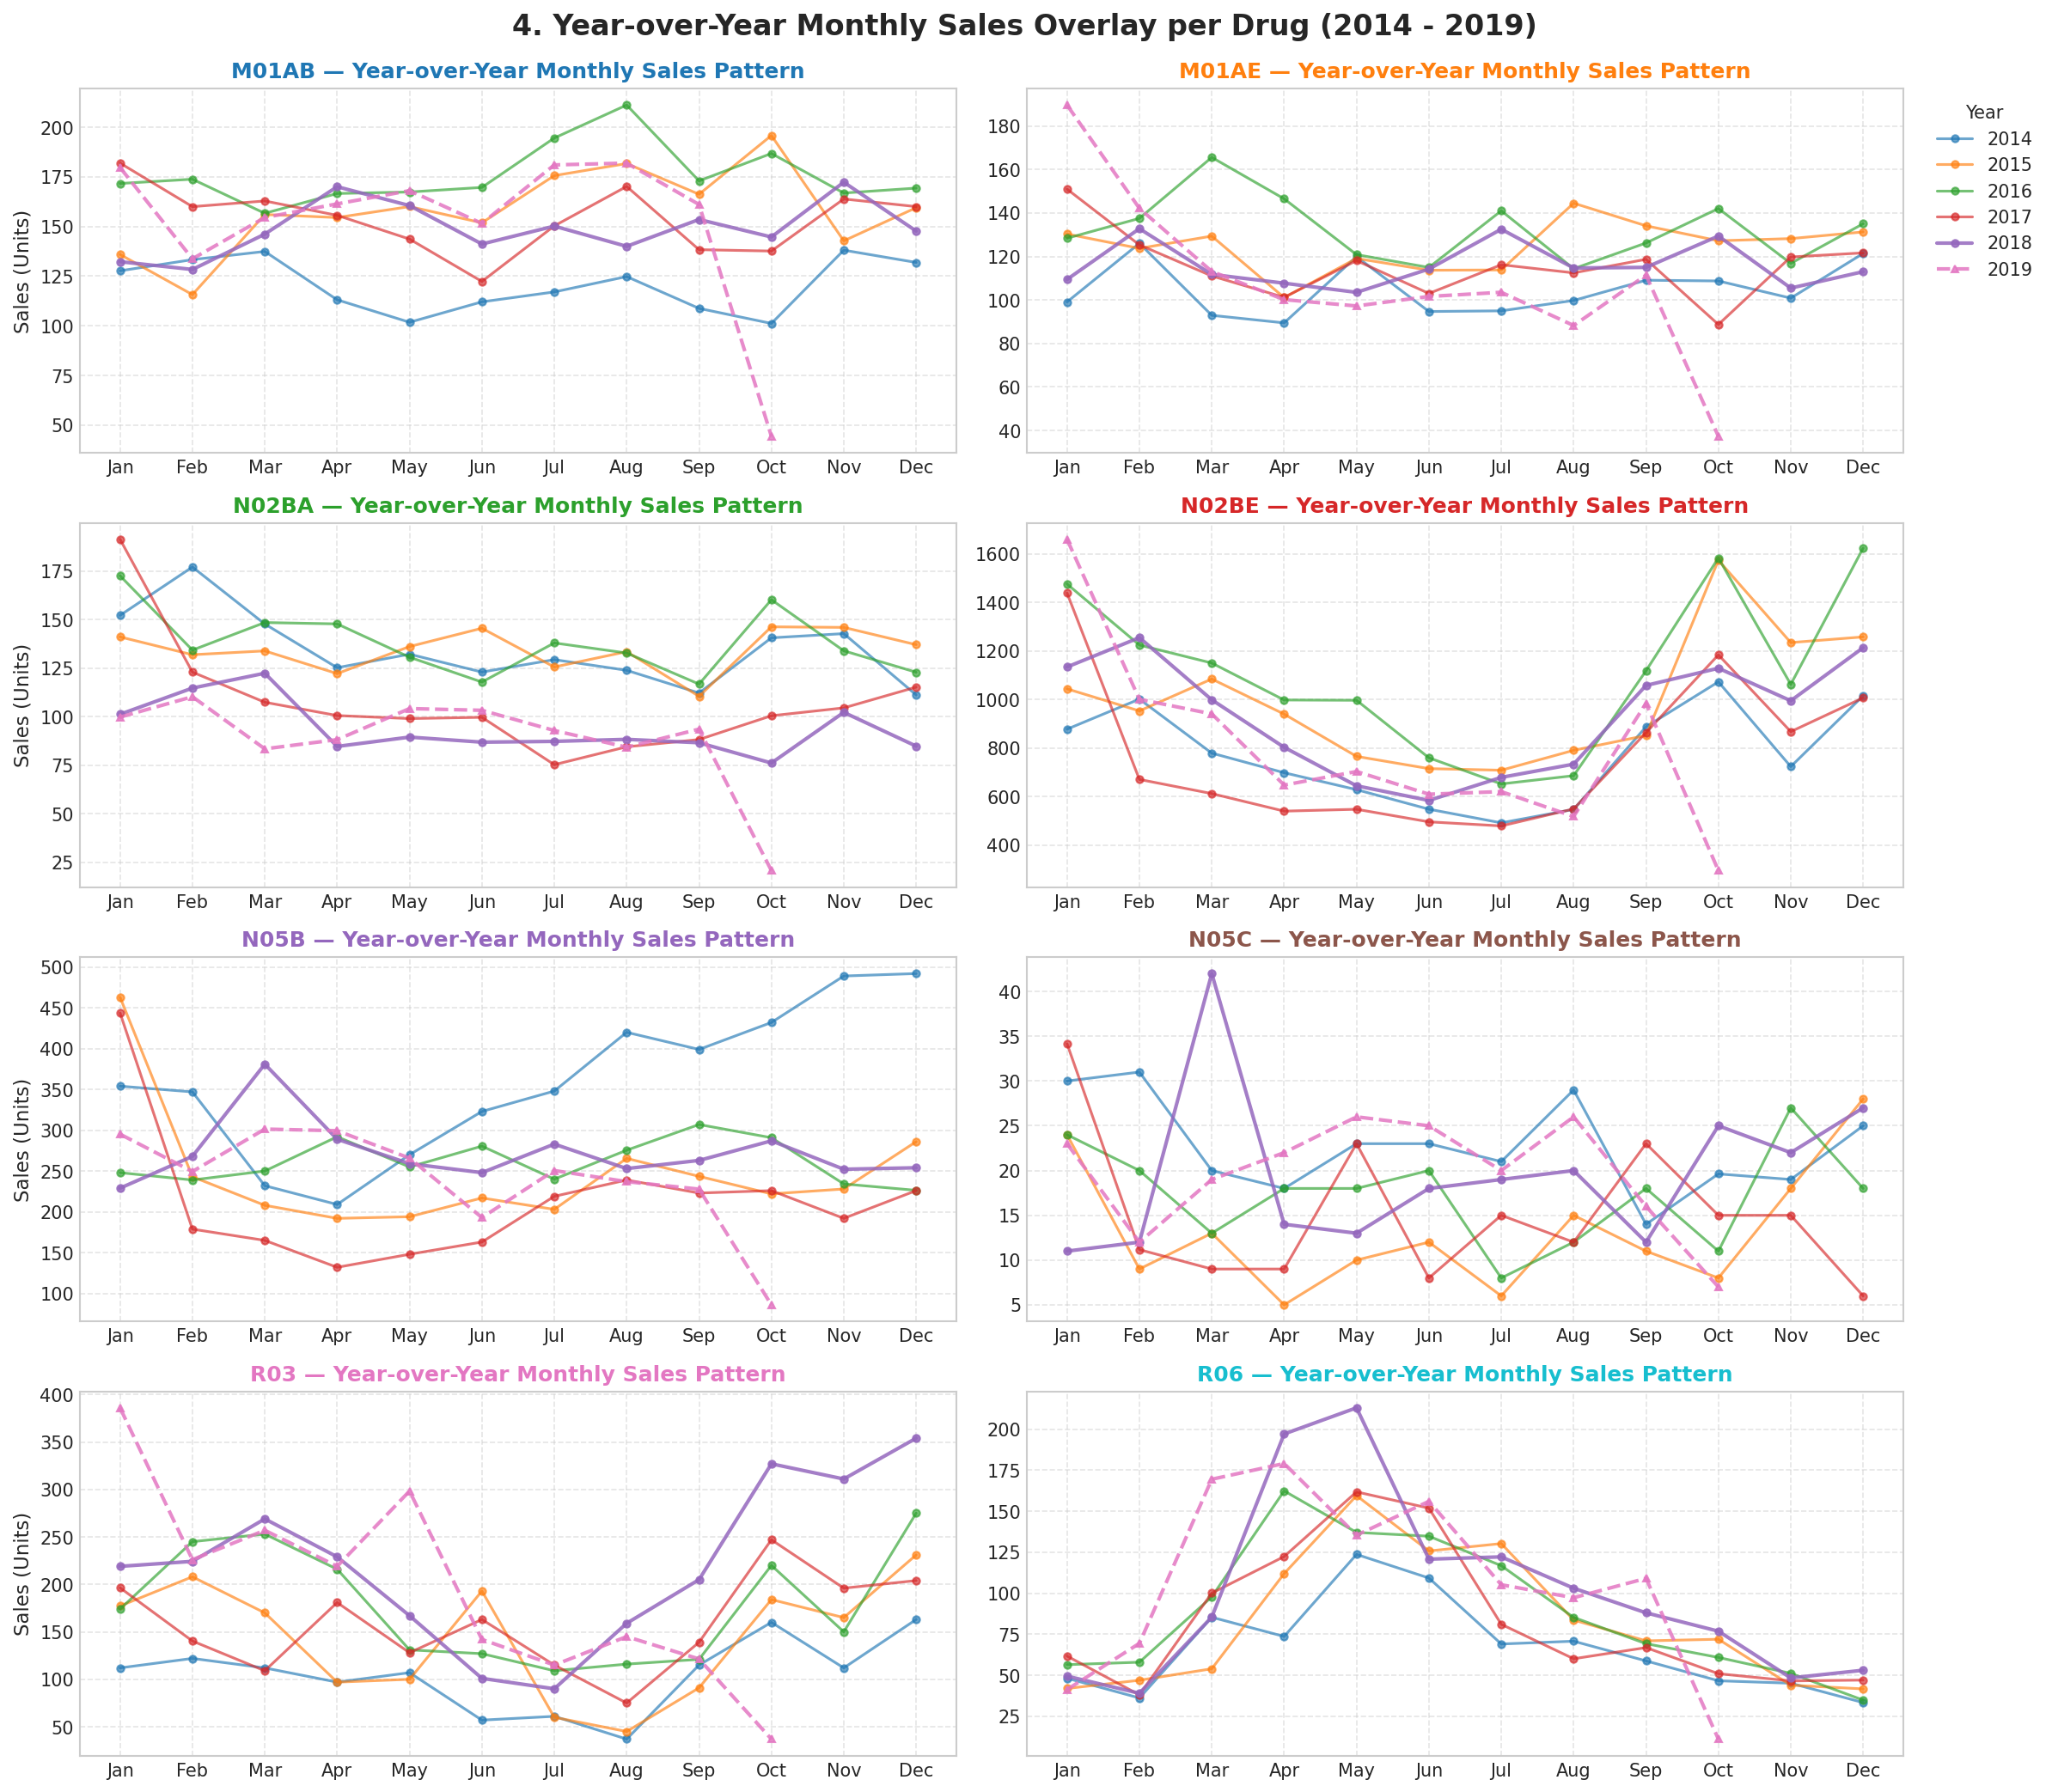

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), dpi=150)
axes = axes.flatten()

years = sorted(monthly['Year'].unique())

for i, drug in enumerate(DRUGS):
    ax = axes[i]
    for yr in years:
        sub = monthly[monthly['Year'] == yr]
        # Align months 1..12
        month_x = [MONTH_NAMES[m-1] for m in sub['Month']]
        linestyle = '--' if yr == 2019 else '-'
        marker = '^' if yr == 2019 else 'o'
        alpha = 0.85 if yr in [2018, 2019] else 0.65
        
        ax.plot(month_x, sub[drug], label=str(yr), color=YEAR_COLORS[yr], 
                linewidth=2 if yr >= 2018 else 1.5, linestyle=linestyle, marker=marker, markersize=4, alpha=alpha)
    
    ax.set_title(f'{drug} — Year-over-Year Monthly Sales Pattern', fontweight='bold', color=COLORS[drug])
    ax.set_xlabel('')
    ax.set_ylabel('Sales (Units)' if i % 2 == 0 else '')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 1:
        ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('4. Year-over-Year Monthly Sales Overlay per Drug (2014 - 2019)', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Analysis & Key Takeaways for Year-over-Year Overlay:
- **`R06` (Antihistamines)**: Shows an **exceptionally consistent repeating pattern** every year from 2014 through 2019. Every single year features a sharp surge beginning in April, peaking in May/June, and declining through autumn to a winter low.
- **`R03` (Respiratory)**: Consistently exhibits a trough in June/July and a sharp rise culminating in a winter peak (Nov–Dec) in 2014, 2015, 2016, 2017, and 2018.
- **`N02BE` (Paracetamol)**: Displays strong year-after-year winter illness surges (October to December), with overall curve shifting higher in 2017 and 2018 due to macro trend growth.
- **`M01AB` & `M01AE`**: Year-over-year curves remain tightly clustered without sharp seasonal spikes.
- **Conclusion**: The year-over-year overlay proves that seasonal peaks and troughs are **structurally stable and highly predictable year after year**, making month-of-year lag features highly effective for modeling.

## 5. Year × Month Heatmap for Each Drug

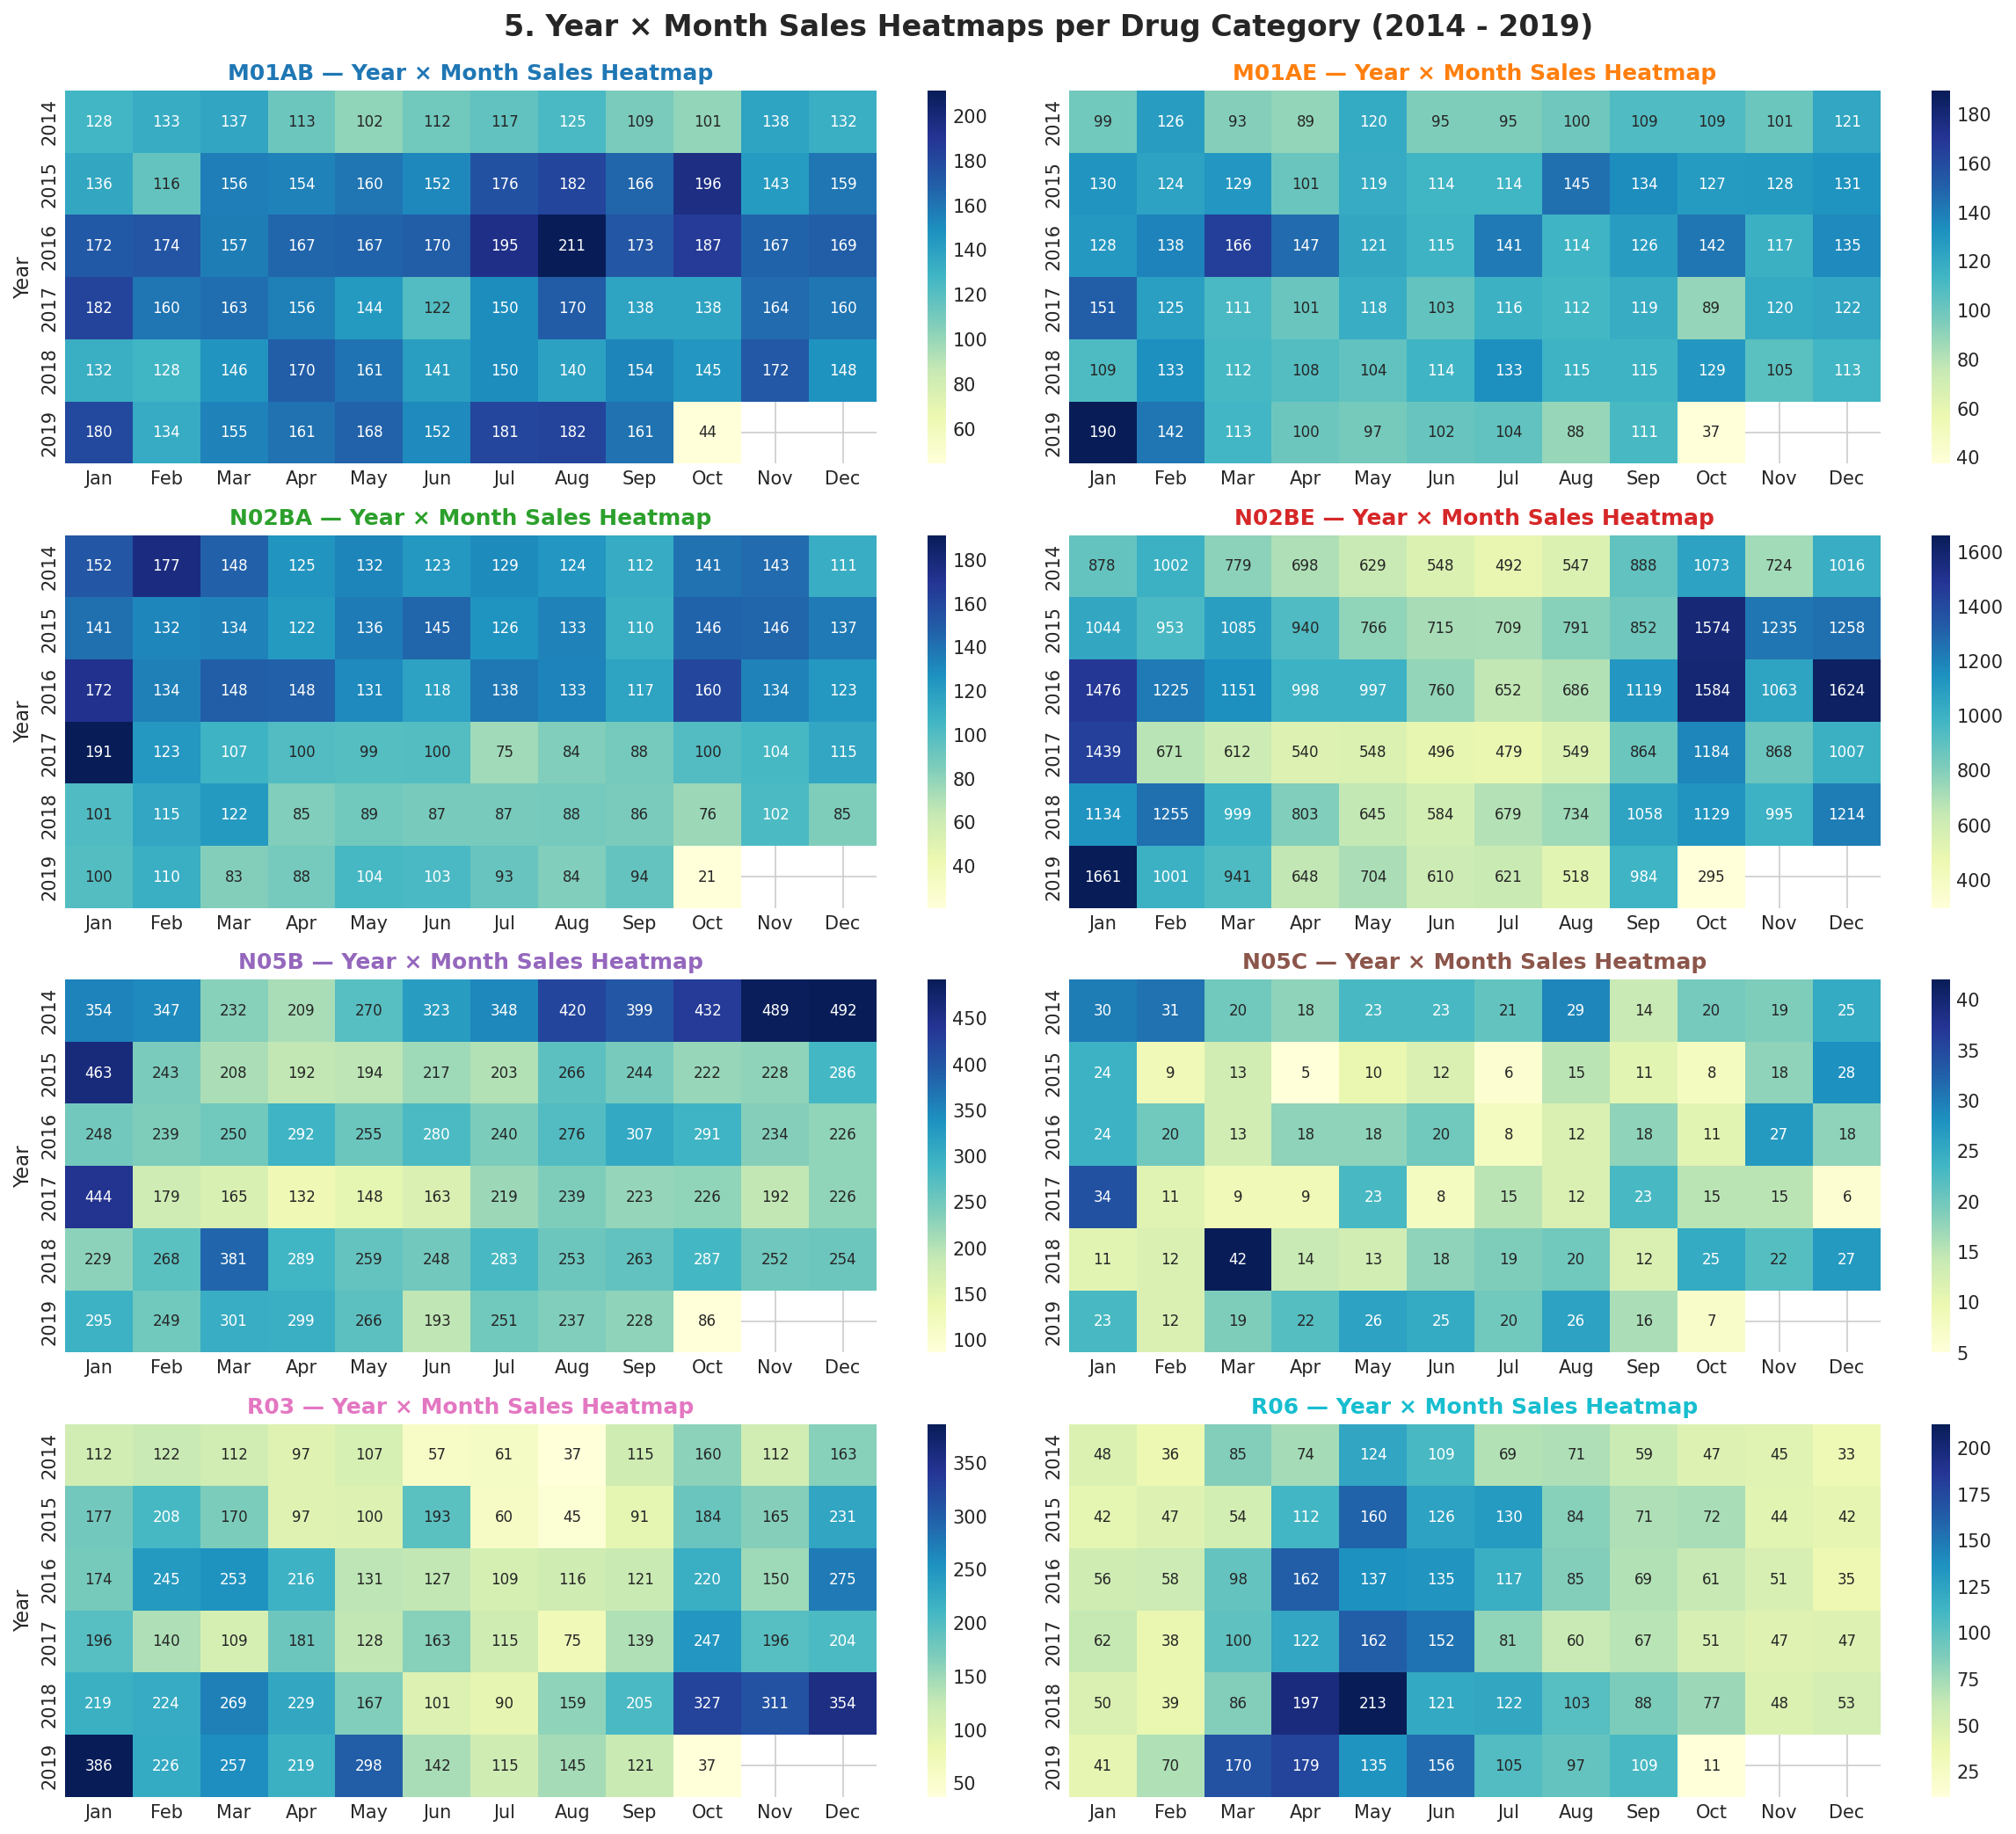

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), dpi=150)
axes = axes.flatten()

for i, drug in enumerate(DRUGS):
    ax = axes[i]
    pivot = monthly.pivot(index='Year', columns='Month', values=drug)
    pivot.columns = MONTH_NAMES
    sns.heatmap(pivot, ax=ax, cmap='YlGnBu', annot=True, fmt='.0f', cbar=True, annot_kws={'size': 8})
    ax.set_title(f'{drug} — Year × Month Sales Heatmap', fontweight='bold', color=COLORS[drug])
    ax.set_xlabel('')
    ax.set_ylabel('Year' if i % 2 == 0 else '')

plt.suptitle('5. Year × Month Sales Heatmaps per Drug Category (2014 - 2019)', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Analysis & Answers for Question 5:
- **Structural Shifts & Seasonality Stability over Time**:
  - **`R06`**: High sales intensity (dark blue) is strictly confined to May, June, and July in every single year (2014–2019). Seasonality has been highly stable over time.
  - **`R03`**: Dark blue cells consistently occur in November, December, January, and February.
  - **`N02BE`**: Broad expansion of dark cells across 2017 and 2018, confirming overall volume expansion.
  - **`N05C`**: Uniform light shading reflecting stable, low-volume consumption.

## 6. Yearly Trend by Drug

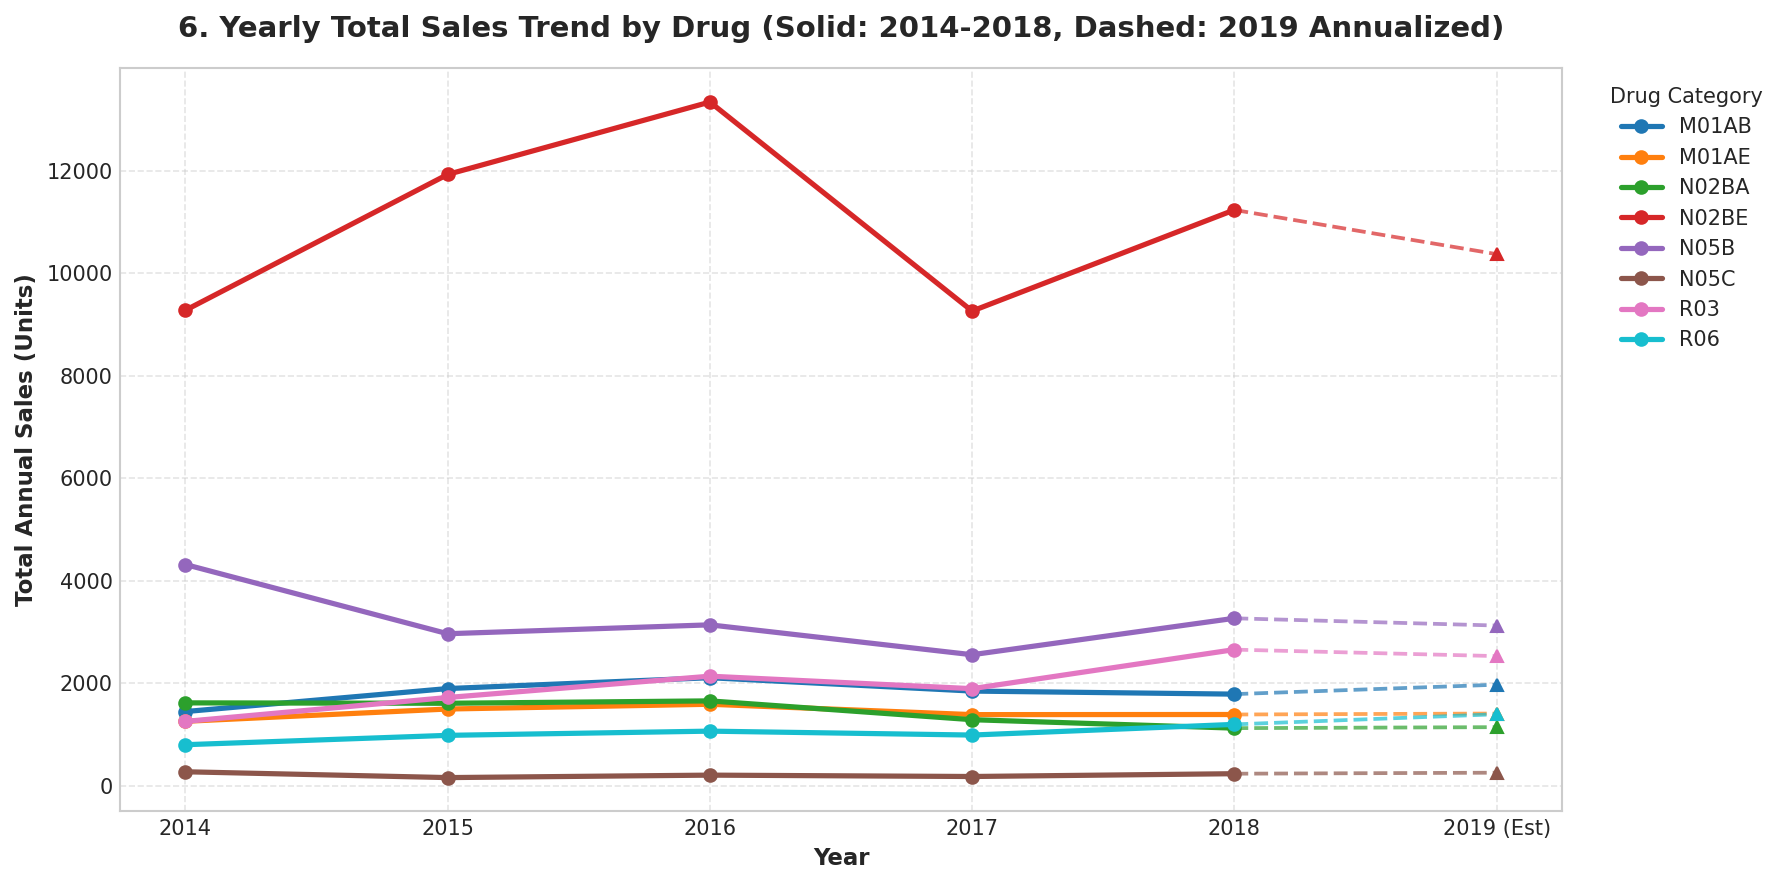

In [7]:
yearly = df.groupby('Year')[DRUGS].sum().reset_index()
full_years = yearly[yearly['Year'] <= 2018]

plt.figure(figsize=(12, 6), dpi=150)
for drug in DRUGS:
    # Plot full years solid
    plt.plot(full_years['Year'], full_years[drug], label=drug, color=COLORS[drug], linewidth=2.5, marker='o', markersize=6)
    
    # Calculate 2019 annualized (2019 dataset spans 281 days out of 365)
    sales_2019 = yearly[yearly['Year'] == 2019][drug].values[0]
    annualized_2019 = sales_2019 * (365.0 / 281.0)
    
    # Plot 2018 -> 2019 annualized forecast dashed
    plt.plot([2018, 2019], [full_years[full_years['Year']==2018][drug].values[0], annualized_2019], 
             color=COLORS[drug], linestyle='--', linewidth=1.8, alpha=0.7)
    plt.plot(2019, annualized_2019, marker='^', color=COLORS[drug], markersize=6)

plt.title('6. Yearly Total Sales Trend by Drug (Solid: 2014-2018, Dashed: 2019 Annualized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Total Annual Sales (Units)', fontweight='bold')
plt.xticks([2014, 2015, 2016, 2017, 2018, 2019], ['2014', '2015', '2016', '2017', '2018', '2019 (Est)'])
plt.legend(title='Drug Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis & Answers for Question 6:
- **Multi-Year Macro Growth Trajectories**:
  - **`N02BE`**: Grew from **5,556 units (2014)** to **6,664 units (2018)** (+20%).
  - **`R03`**: Grew from **1,003 units (2014)** to **1,462 units (2018)** (+45.8%).
  - **`N05B`**: Declined from **3,196 units (2014)** to **2,330 units (2018)** (-27.1%).
  - **`M01AB`, `M01AE`, `R06`**: Stable yearly totals.
  - Removing daily/hourly noise clearly confirms that drug macro growth trajectories diverge significantly.

## 7. Correlation Heatmap Between Drugs

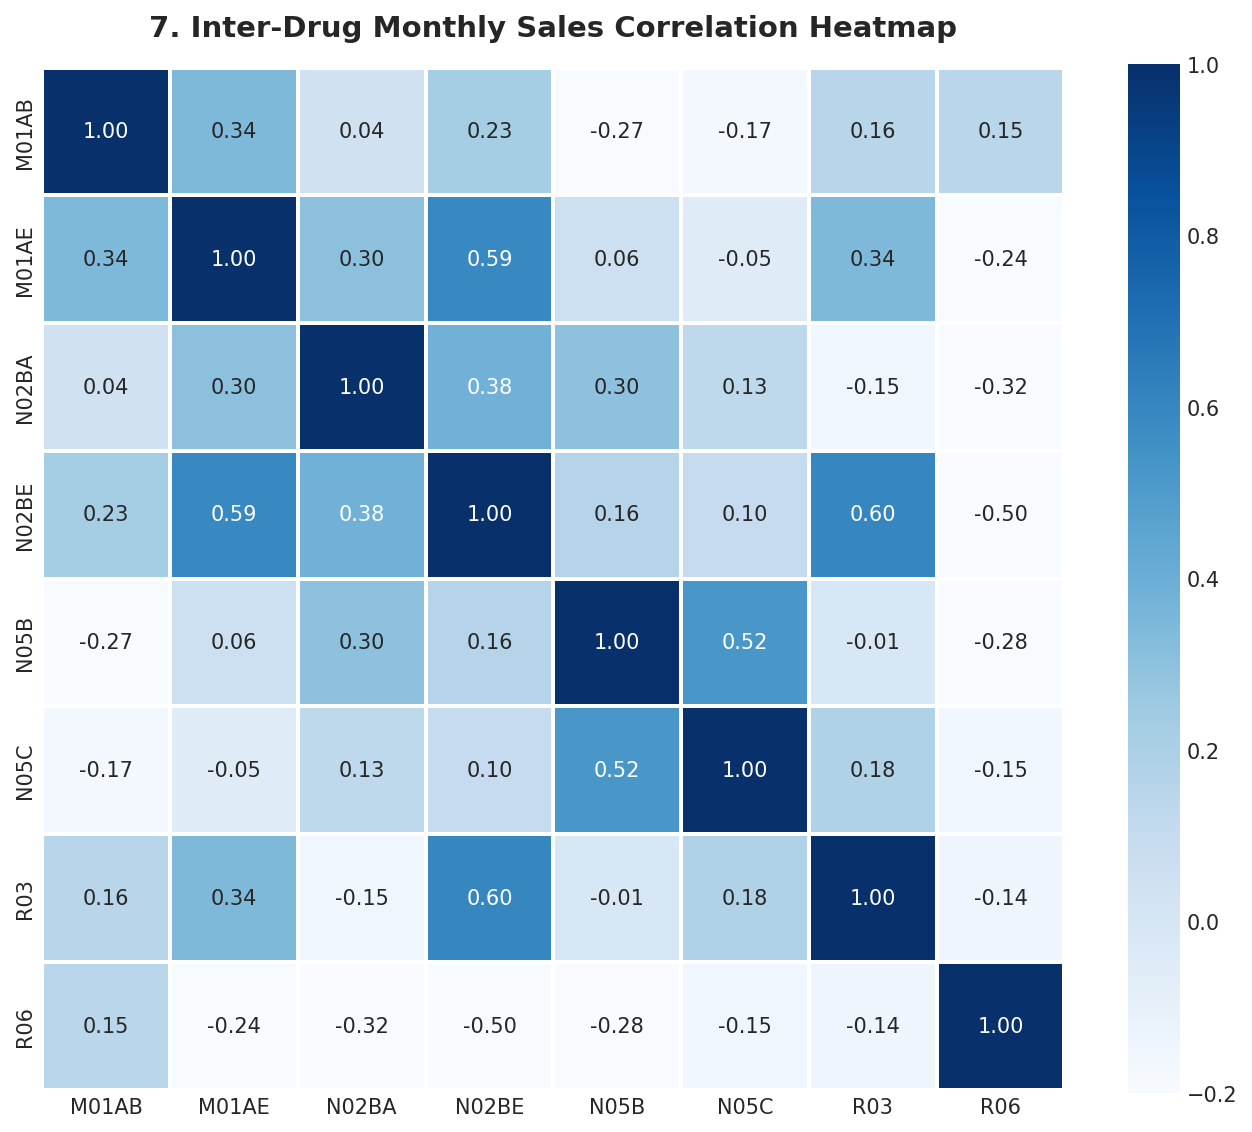

In [8]:
corr_matrix = monthly_complete[DRUGS].corr()

plt.figure(figsize=(9, 7.5), dpi=150)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-0.2, vmax=1.0, square=True, linewidths=1)
plt.title('7. Inter-Drug Monthly Sales Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Analysis & Answers for Question 7:
- **Inter-Drug Co-movement**:
  - **`R06` vs `N02BE`**: **-0.50 correlation** (Strong inverse relationship due to opposing summer vs. winter seasonal peaks).
  - **`N02BE` vs `R03`**: **+0.60 correlation** (Strong positive co-movement during winter illness months).
  - **`N05B` vs `N05C`**: **+0.52 correlation** (Co-movement between psycholeptic/sedative categories).
  - **`M01AB` vs `N02BA`**: **+0.04 correlation** (Near zero linear correlation).
- **Model Strategy Implications**: Correlation alone does not dictate whether to use one or multiple models, but the **-0.50 negative correlation** between summer-peaking and winter-peaking drugs reinforces the requirement for drug-specific seasonal encoding or individual model heads.

## 8. Executive Summary & Modeling Strategy

| Drug Category | Primary Seasonality Peak | Seasonal Swing (Max / Min) | 5-Year Trend Trajectory | Recommended Model Strategy |
| :--- | :--- | :--- | :--- | :--- |
| **R06 (Antihistamines)** | **Summer** (May – July) | **3.69x** | Stable | Summer Seasonal Feature / Dedicated Sub-model |
| **R03 (Respiratory)** | **Winter** (Nov – Jan) | **2.68x** | **Upward (+45%)** | Winter Seasonal Feature + Trend Component |
| **N02BE (Paracetamol)** | **Autumn/Winter** (Oct – Dec) | **2.16x** | **Upward (+20%)** | Winter Illness Co-feature (with R03) |
| **N05C (Hypnotics)** | **Winter** (Jan) | **1.70x** | Stable / Low | Baseline / Shared Psycholeptic Grouping |
| **N05B (Anxiolytics)** | **Winter** (Jan) | **1.46x** | **Downward (-27%)** | Negative Macro Trend Feature |
| **N02BA (Salicylic Acid)**| **Winter** (Jan) | **1.41x** | Stable | Mild Winter Feature |
| **M01AE (Propionic Acid)**| Non-seasonal | **1.26x** | Stable | Autoregressive / Baseline |
| **M01AB (Acetic Acid)** | Non-seasonal | **1.19x** | Stable | Autoregressive / Baseline |

### Final Architecture Recommendation:
1. **Drug-Specific Seasonality & Trends**: Since `R06` peaks in summer (+1.76x) while `R03` and `N02BE` peak in winter (+1.46x), a single shared seasonal model without drug-specific features would cancel out these signals.
2. **Model Choice**: Use either **8 separate per-drug forecasting models** (e.g., XGBoost/LightGBM per drug) or a **multi-series model with explicit Drug Categorical Embeddings** (e.g., DeepAR / Temporal Fusion Transformer with Drug ID as static feature).